# Hough Tuner

This notebook processes a single input image in three stages:
1. threshold the image using one saved HSV color preset,
2. apply tunable Canny on that threshold mask,
3. apply tunable rectangular Hough on the generated edge image.


In [1]:
from __future__ import annotations

import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import clear_output, display

try:
    import ipywidgets as widgets
except ImportError as exc:
    raise ImportError(
        "ipywidgets is required for this notebook. Install it in your notebook kernel with: pip install ipywidgets"
    ) from exc


BASE_DIR = Path.cwd()
TARGET_IMAGE_PATH = BASE_DIR / "iapr-26-uno-vision-challenge" / "reference_images" / "L1000766.jpg"
THRESHOLD_COLOR = "yellow"
HSV_FILE_PATH = BASE_DIR / f"{THRESHOLD_COLOR}_hsv.txt"
CANNY_SETTINGS_PATH = BASE_DIR / "canny_set.txt"
HOUGH_SETTINGS_PATH = BASE_DIR / "hough_set.txt"
GENERATED_EDGE_PATH = BASE_DIR / "iapr-26-uno-vision-challenge" / "cards" / f"{TARGET_IMAGE_PATH.stem}_{THRESHOLD_COLOR}_canny_generated.png"
SCALE = 0.25
HSV_ARRAY_PATTERN = re.compile(r"np\.array\(\s*\[([^\]]+)\]\s*\)")
KEY_VALUE_PATTERN = re.compile(r"^\s*([^:]+)\s*:\s*(\d+)\s*$", re.MULTILINE)


def parse_hsv_file(path: Path) -> list[tuple[np.ndarray, np.ndarray]]:
    text = path.read_text(encoding="utf-8")
    arrays = []
    for match in HSV_ARRAY_PATTERN.finditer(text):
        values = [int(value.strip()) for value in match.group(1).split(",")]
        arrays.append(np.array(values, dtype=np.uint8))
    if len(arrays) % 2 != 0 or not arrays:
        raise ValueError(f"Expected lower/upper HSV pairs in {path}")
    return list(zip(arrays[0::2], arrays[1::2]))


def threshold_image(image_bgr: np.ndarray, ranges: list[tuple[np.ndarray, np.ndarray]]) -> np.ndarray:
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    combined_mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        combined_mask = cv2.bitwise_or(combined_mask, cv2.inRange(hsv, lower, upper))
    return combined_mask


def load_canny_settings(path: Path) -> dict[str, int]:
    settings = {key.strip().lower().replace(" ", "_"): int(value) for key, value in KEY_VALUE_PATTERN.findall(path.read_text(encoding="utf-8"))}
    required = {"blur", "low", "high", "min_len"}
    missing = required - settings.keys()
    if missing:
        raise ValueError(f"Missing Canny settings in {path}: {sorted(missing)}")
    if settings["blur"] % 2 == 0:
        settings["blur"] += 1
    return settings


def save_canny_settings(path: Path, blur: int, low: int, high: int, min_len: int) -> None:
    path.write_text(
        f"Blur: {blur}\nLow: {low}\nHigh: {high}\nMin len: {min_len}\n",
        encoding="utf-8",
    )


def load_hough_settings(path: Path) -> dict[str, int]:
    defaults = {
        "min_support": 45,
        "angle_step": 5,
        "edge_tolerance": 2,
        "rect_width": 60,
        "rect_height": 90,
        "max_candidates": 20,
    }
    if not path.exists():
        return defaults

    settings = {
        key.strip().lower().replace(" ", "_"): int(value)
        for key, value in KEY_VALUE_PATTERN.findall(path.read_text(encoding="utf-8"))
    }

    # Backward compatibility with the previous Hough-line settings file.
    if "threshold" in settings and "min_support" not in settings:
        settings["min_support"] = settings["threshold"]
    if "max_gap" in settings and "edge_tolerance" not in settings:
        settings["edge_tolerance"] = settings["max_gap"]

    defaults.update({key: settings[key] for key in defaults.keys() if key in settings})
    defaults["angle_step"] = max(1, defaults["angle_step"])
    defaults["edge_tolerance"] = max(0, defaults["edge_tolerance"])
    return defaults


def save_hough_settings(path: Path, settings: dict[str, int]) -> None:
    path.write_text(
        "\n".join([
            f"Min support: {settings['min_support']}",
            f"Angle step: {settings['angle_step']}",
            f"Edge tolerance: {settings['edge_tolerance']}",
            f"Rect width: {settings['rect_width']}",
            f"Rect height: {settings['rect_height']}",
            f"Max candidates: {settings['max_candidates']}",
        ]) + "\n",
        encoding="utf-8",
    )


def filter_short_contours(edges: np.ndarray, min_length: int) -> np.ndarray:
    if min_length <= 0:
        return edges
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    filtered = np.zeros_like(edges)
    for contour in contours:
        if cv2.arcLength(contour, closed=True) >= min_length:
            cv2.drawContours(filtered, [contour], -1, 255, thickness=2)
    return filtered


def rectangle_template(width: int, height: int, angle: int) -> tuple[np.ndarray, np.ndarray]:
    pad = 3
    diagonal = int(np.ceil(np.hypot(width, height))) + 2 * pad
    size = max(diagonal, width + 2 * pad, height + 2 * pad)
    if size % 2 == 0:
        size += 1

    center = (size // 2, size // 2)
    template = np.zeros((size, size), dtype=np.uint8)
    rect = (center, (width, height), angle)
    box = cv2.boxPoints(rect).astype(np.int32)
    cv2.polylines(template, [box], True, 1, thickness=1)

    ys, xs = np.where(template > 0)
    return template.astype(np.float32), np.column_stack([xs - center[0], ys - center[1]])


def nms_rectangles(candidates: list[dict], max_candidates: int, min_center_distance: float) -> list[dict]:
    kept = []
    for candidate in sorted(candidates, key=lambda item: item['score'], reverse=True):
        center = np.array(candidate['center'])
        if any(np.linalg.norm(center - np.array(item['center'])) < min_center_distance for item in kept):
            continue
        kept.append(candidate)
        if len(kept) >= max_candidates:
            break
    return kept


def rectangular_hough(edges: np.ndarray, hough_settings: dict[str, int]) -> list[dict]:
    width = hough_settings['rect_width']
    height = hough_settings['rect_height']
    min_support = hough_settings['min_support'] / 100.0
    angle_step = hough_settings['angle_step']
    edge_tolerance = hough_settings['edge_tolerance']
    max_candidates = hough_settings['max_candidates']

    edge_binary = (edges > 0).astype(np.uint8)
    if edge_tolerance > 0:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (2 * edge_tolerance + 1, 2 * edge_tolerance + 1),
        )
        edge_binary = cv2.dilate(edge_binary, kernel)
    edge_binary = edge_binary.astype(np.float32)
    candidates = []

    for angle in range(0, 180, angle_step):
        template, offsets = rectangle_template(width, height, angle)
        if template.shape[0] > edges.shape[0] or template.shape[1] > edges.shape[1]:
            continue
        support_pixels = float(np.count_nonzero(template))
        if support_pixels == 0:
            continue

        votes = cv2.matchTemplate(edge_binary, template, cv2.TM_CCORR)
        support = votes / support_pixels
        local_max = support == cv2.dilate(support, np.ones((5, 5), dtype=np.float32))
        y_positions, x_positions = np.where((support >= min_support) & local_max)
        template_center = template.shape[0] // 2

        for y, x in zip(y_positions, x_positions):
            center = (int(x + template_center), int(y + template_center))
            score = float(support[y, x])
            box_points = offsets + np.array(center)
            x0, y0 = box_points.min(axis=0)
            x1, y1 = box_points.max(axis=0)
            if x0 < 0 or y0 < 0 or x1 >= edges.shape[1] or y1 >= edges.shape[0]:
                continue
            rect = (center, (width, height), angle)
            box = cv2.boxPoints(rect).astype(np.int32).reshape(-1, 1, 2)
            x_box, y_box, w_box, h_box = cv2.boundingRect(box)
            candidates.append({
                'score': score,
                'support': score,
                'angle': angle,
                'center': center,
                'box': box,
                'bounds': (x_box, y_box, w_box, h_box),
            })

    min_center_distance = 0.5 * min(width, height)
    return nms_rectangles(candidates, max_candidates, min_center_distance)


image_bgr = cv2.imread(str(TARGET_IMAGE_PATH))
if image_bgr is None:
    raise FileNotFoundError(f"Could not load target image: {TARGET_IMAGE_PATH}")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
threshold_ranges = parse_hsv_file(HSV_FILE_PATH)
canny_defaults = load_canny_settings(CANNY_SETTINGS_PATH)
hough_defaults = load_hough_settings(HOUGH_SETTINGS_PATH)
state = {"mask": None, "edges": None, "edge_path": GENERATED_EDGE_PATH}

print(f"Target image: {TARGET_IMAGE_PATH}")
print(f"Threshold color: {THRESHOLD_COLOR}")
print(f"HSV settings: {HSV_FILE_PATH}")
print(f"Canny settings: {CANNY_SETTINGS_PATH}")
print(f"Hough settings: {HOUGH_SETTINGS_PATH}")


Target image: /Users/JC/Desktop/Image Analysis/IAPR_gr69/project/iapr-26-uno-vision-challenge/reference_images/L1000766.jpg
Threshold color: yellow
HSV settings: /Users/JC/Desktop/Image Analysis/IAPR_gr69/project/yellow_hsv.txt
Canny settings: /Users/JC/Desktop/Image Analysis/IAPR_gr69/project/canny_set.txt
Hough settings: /Users/JC/Desktop/Image Analysis/IAPR_gr69/project/hough_set.txt


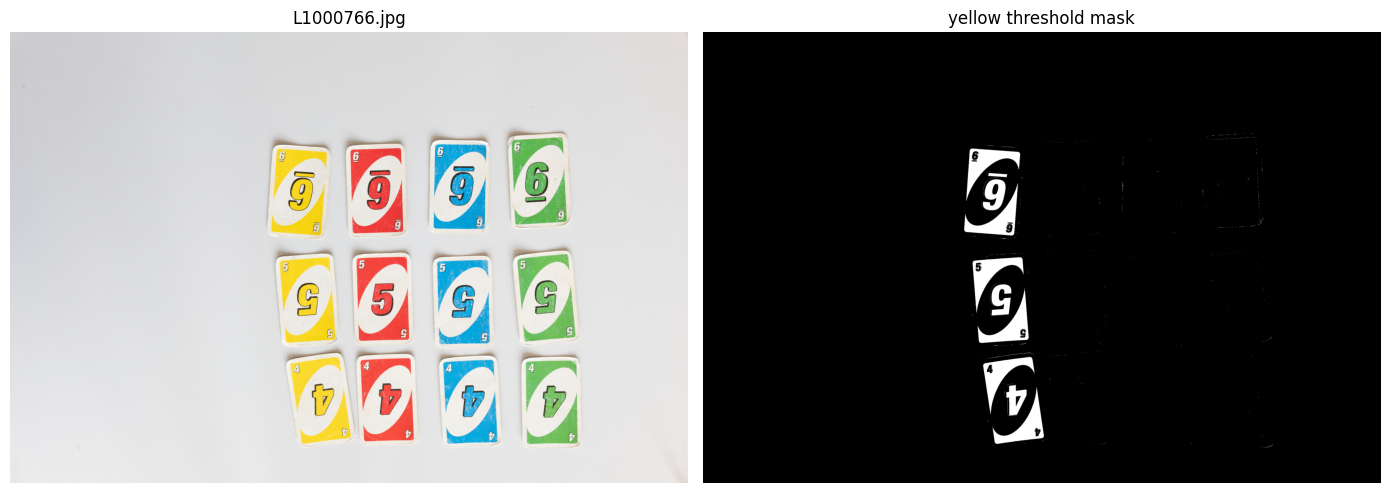

In [2]:
threshold_mask = threshold_image(image_bgr, threshold_ranges)
state['mask'] = threshold_mask

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(image_rgb)
axes[0].set_title(TARGET_IMAGE_PATH.name)
axes[0].axis('off')

axes[1].imshow(threshold_mask, cmap='gray')
axes[1].set_title(f'{THRESHOLD_COLOR} threshold mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [3]:
if state.get('mask') is None:
    threshold_mask = threshold_image(image_bgr, threshold_ranges)
    state['mask'] = threshold_mask

blur_slider = widgets.IntSlider(value=canny_defaults['blur'], min=1, max=31, step=2, description='Blur')
low_slider = widgets.IntSlider(value=canny_defaults['low'], min=0, max=255, step=1, description='Low')
high_slider = widgets.IntSlider(value=canny_defaults['high'], min=0, max=255, step=1, description='High')
min_len_slider = widgets.IntSlider(value=canny_defaults['min_len'], min=0, max=1000, step=5, description='Min len')
save_canny_button = widgets.Button(description='Save Canny', button_style='success')
canny_status = widgets.Output()
canny_preview = widgets.Output()


def update_canny(*_):
    mask = state['mask']
    blur_size = blur_slider.value
    low = min(low_slider.value, high_slider.value)
    high = max(low_slider.value, high_slider.value)
    min_len = min_len_slider.value

    blurred = cv2.GaussianBlur(mask, (blur_size, blur_size), 0)
    edges = cv2.Canny(blurred, low, high)
    edges = filter_short_contours(edges, min_len)
    edges = cv2.dilate(edges, np.ones((3, 3), dtype=np.uint8), iterations=1)

    state['edges'] = edges
    state['edge_path'].parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(state['edge_path']), edges)

    with canny_preview:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        axes[0].imshow(mask, cmap='gray')
        axes[0].set_title('Threshold mask')
        axes[0].axis('off')

        axes[1].imshow(blurred, cmap='gray')
        axes[1].set_title(f'Blurred mask (blur={blur_size})')
        axes[1].axis('off')

        axes[2].imshow(edges, cmap='gray')
        axes[2].set_title(state['edge_path'].name)
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

    with canny_status:
        clear_output(wait=True)
        print(f"Saved generated edge image to: {state['edge_path']}")
        print(f'Current settings: blur={blur_size}, low={low}, high={high}, min_len={min_len}')


def save_canny(_):
    blur_size = blur_slider.value
    low = min(low_slider.value, high_slider.value)
    high = max(low_slider.value, high_slider.value)
    min_len = min_len_slider.value
    save_canny_settings(CANNY_SETTINGS_PATH, blur_size, low, high, min_len)
    update_canny()
    with canny_status:
        print('Canny settings saved.')


for slider in (blur_slider, low_slider, high_slider, min_len_slider):
    slider.observe(update_canny, names='value')

save_canny_button.on_click(save_canny)

display(widgets.VBox([widgets.HBox([blur_slider, low_slider, high_slider, min_len_slider]), save_canny_button, canny_status, canny_preview]))

update_canny()


In [ ]:
if state.get('edges') is None:
    raise RuntimeError('Run the Canny cell first so the edge image exists.')

min_support_slider = widgets.IntSlider(value=hough_defaults['min_support'], min=1, max=100, step=1, description='Min support')
angle_step_slider = widgets.IntSlider(value=hough_defaults['angle_step'], min=1, max=30, step=1, description='Angle step')
edge_tolerance_slider = widgets.IntSlider(value=hough_defaults['edge_tolerance'], min=0, max=10, step=1, description='Edge tol')
rect_width_slider = widgets.IntSlider(value=hough_defaults['rect_width'], min=5, max=300, step=1, description='Rect width')
rect_height_slider = widgets.IntSlider(value=hough_defaults['rect_height'], min=5, max=300, step=1, description='Rect height')
max_candidates_slider = widgets.IntSlider(value=hough_defaults['max_candidates'], min=1, max=100, step=1, description='Max rects')
save_hough_button = widgets.Button(description='Save Hough', button_style='success')
hough_status = widgets.Output()
hough_preview = widgets.Output()


def current_hough_settings() -> dict[str, int]:
    return {
        'min_support': min_support_slider.value,
        'angle_step': angle_step_slider.value,
        'edge_tolerance': edge_tolerance_slider.value,
        'rect_width': rect_width_slider.value,
        'rect_height': rect_height_slider.value,
        'max_candidates': max_candidates_slider.value,
    }


def update_hough(*_):
    settings = current_hough_settings()
    edges = state['edges']
    small_edges = cv2.resize(edges, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_NEAREST)
    overlay_small = cv2.resize(image_rgb, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_NEAREST)

    candidates = rectangular_hough(small_edges, settings)
    result_rgb = overlay_small.copy()
    contribution_canvas = cv2.cvtColor(small_edges, cv2.COLOR_GRAY2RGB)

    for rank, candidate in enumerate(candidates, start=1):
        box = candidate['box']
        x, y, _, _ = candidate['bounds']
        color = (255, 0, 0) if rank == 1 else (255, 180, 0)
        cv2.polylines(result_rgb, [box], True, color, 2)
        cv2.polylines(contribution_canvas, [box], True, color, 1)
        cv2.putText(result_rgb, f'#{rank}', (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

    with hough_preview:
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, 7))
        axes[0].imshow(small_edges, cmap='gray')
        axes[0].set_title(state['edge_path'].name)
        axes[0].axis('off')

        axes[1].imshow(contribution_canvas)
        axes[1].set_title('Rectangle edge support')
        axes[1].axis('off')

        axes[2].imshow(result_rgb)
        axes[2].set_title('Valid rectangles on image')
        axes[2].axis('off')

        plt.tight_layout()
        plt.show()

    with hough_status:
        clear_output(wait=True)
        print(f'Settings file: {HOUGH_SETTINGS_PATH}')
        print(f"Min support: {settings['min_support']}%")
        print(f"Angle step: {settings['angle_step']} degrees")
        print(f"Edge tolerance: {settings['edge_tolerance']} px")
        print(f"Rectangle size: {settings['rect_width']} x {settings['rect_height']} px at preview scale")
        print(f'Rectangle candidates kept: {len(candidates)}')


def save_hough(_):
    save_hough_settings(HOUGH_SETTINGS_PATH, current_hough_settings())
    update_hough()
    with hough_status:
        print('Hough settings saved.')


for widget in (
    min_support_slider,
    angle_step_slider,
    edge_tolerance_slider,
    rect_width_slider,
    rect_height_slider,
    max_candidates_slider,
):
    widget.observe(update_hough, names='value')

save_hough_button.on_click(save_hough)

display(widgets.VBox([
    widgets.HBox([min_support_slider, angle_step_slider, edge_tolerance_slider]),
    widgets.HBox([rect_width_slider, rect_height_slider, max_candidates_slider]),
    save_hough_button,
    hough_status,
    hough_preview,
]))

update_hough()
